# The goal of this notebook is to implement the DASC algorithm (doi:  https://doi.org/10.7554/eLife.53686) on our AP2 tracks

In [1]:
#Load all the tracks
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Load the pickle file
with open('filtered_tracks_final_aadarsh_copy.pkl', 'rb') as f:
    data = pickle.load(f)

# Convert to DataFrame
df = pd.DataFrame(data)

tracks = [] # stores AP2 tracks
ids = []
for _, row in df.iterrows():
    track_id = row['track_id']
    ids.append(track_id)
    c1 = list(row['C1_adjusted_voxel_sum'])
    c2 = list(row['C2_adjusted_voxel_sum'])
    c3 = list(row['C3_adjusted_voxel_sum']) # AP2 channel
    tracks.append(c3)
    

Text(0, 0.5, 'Intensity')

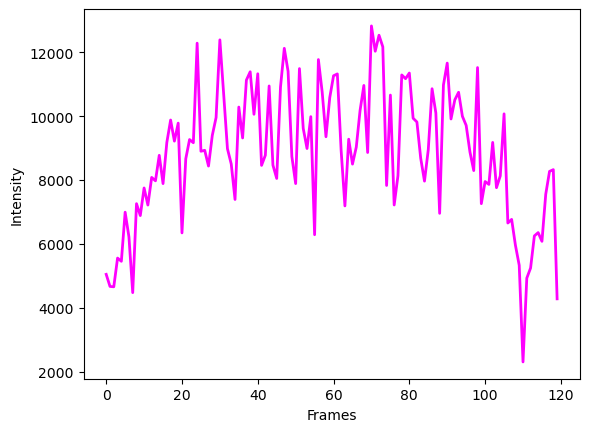

In [2]:
# Plot an example track
plt.plot(tracks[1], color='magenta', linewidth=2)
plt.xlabel('Frames')
plt.ylabel('Intensity')

## Implementing DASC: discretize the AP2 tracks into states

In [3]:
from collections import Counter
# Parameters: Upper threshold - Tracks that have intensities higher than this threshold are pruned to allow enough transitions between states.
# state_size: how big is each state in units of intensitites

state_size = 1000
upper_threshold = 8000
tracks_states = []
analysed_tracks = []
for x in tracks:
    skip = 0 
    for i in x:
        if i > upper_threshold:
            skip =1 
    if skip:
        continue
    states = [int(i // state_size) if i > 0 else 0 for i in x]
    tracks_states.append(states)
    analysed_tracks.append(x)

num_states = int(upper_threshold//state_size)+1

print(len(tracks_states))

9974


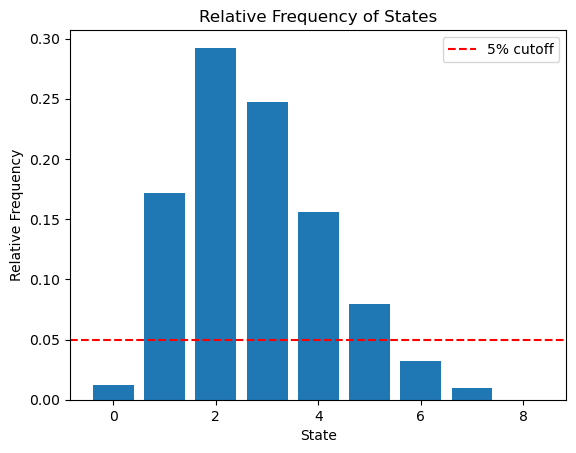

In [4]:
import matplotlib.pyplot as plt
from collections import Counter

# Flatten list of lists
all_states = [state for track in tracks_states for state in track]

# Count occurrences
counts = Counter(all_states)

# Compute relative frequencies
total = sum(counts.values())
relative_freq_list = [
    counts.get(state, 0) / total
    for state in range(num_states)
]

# Plot
plt.bar(range(num_states), relative_freq_list)
plt.axhline(0.05, color='red', linestyle='--', label='5% cutoff')  # cutoff line
plt.xlabel("State")
plt.ylabel("Relative Frequency")
plt.title("Relative Frequency of States")
plt.legend()
plt.show()


In [5]:
# Calculate the transition matrix W
def get_W(tracks_states, t ,num_states):

    W = np.zeros((num_states, num_states))
    counter = np.zeros((num_states,num_states))
    for x in range(len(tracks_states)):
        track = tracks_states[x]
        if len(track) < t+2:
            continue
        else:
            s1 = track[t]
            s2 = track[t+1]
            counter[s1, s2] += 1 

    rows = counter.sum(axis=1)
    for i in range(num_states):
        for j in range(num_states):
            if(rows[i] != 0 ):
                W[i][j] = counter[i][j]/rows[i]
            else:
                W[i][j] = 0 


    return W
    
t_max = max([len(x) for x in tracks_states])
all_W = []
for t in range(t_max):
    all_W.append(get_W(tracks_states,t, num_states))

    
    

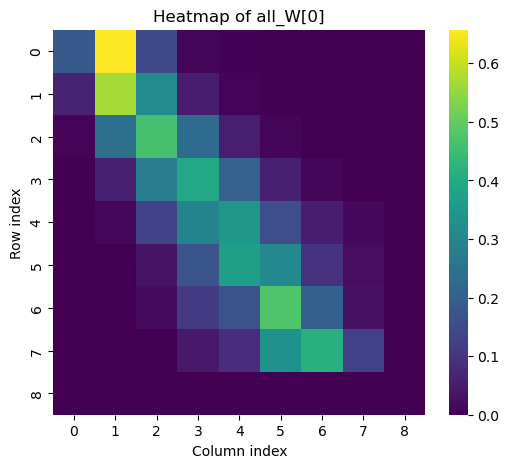

In [6]:
# Visualize the transition matrix at time t=0
import seaborn as sns
# Convert to numpy array just in case
data = np.array(all_W[0])

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(data, cmap="viridis")
plt.title("Heatmap of all_W[0]")
plt.xlabel("Column index")
plt.ylabel("Row index")
plt.show()


In [7]:
# Use this cell to save an animation of the transition matrix over time
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(6,5))

def update(t):
    ax.clear()
    im = ax.imshow(
        all_W[t].T,
        cmap='viridis',
        aspect='auto',
        interpolation='nearest',
        vmin=np.min(all_W[0]),
        vmax=np.max(all_W[0]),
        origin='lower'
    )
    size = all_W[0].shape[0]
    ax.plot(np.arange(size), np.arange(size), color='red', linewidth=1.5)
    ax.set_title(f'W matrix at t = {t} (i on x-axis, j on y-axis)')
    ax.set_xlabel('State i')
    ax.set_ylabel('State j')
    ax.set_xticks(np.arange(size))
    ax.set_yticks(np.arange(size))
    return im,

ani = animation.FuncAnimation(fig, update, frames=len(all_W), blit=False)

# Save as mp4 (requires ffmpeg or mencoder installed)
ani.save('W_matrix_animation.mp4', writer='ffmpeg', fps=5)

plt.close(fig)


# The next step is to aggregate the transition matrices into the global statistics matrix D

In [8]:
def global_D(all_W,t_max, num_states):
    D = np.zeros((num_states, t_max))
    for i in range(num_states):
        for t in range(t_max):
            sum_left = 0
            sum_right = 0
            for k in range(0,i+1):
                if (k== i):
                    sum_right += all_W[t][k,i]
                else:
                    sum_left += all_W[t][i,k]
                    sum_right += all_W[t][k,i]
            if (sum_left == 0 or sum_right== 0):
                D[i][t] = 0 
            else:
                l = np.log(sum_left)
                r = np.log(sum_right)
                D[i][t] = l-r

    return D 

In [9]:
D = global_D(all_W,t_max, num_states)

Track min/max: 0 5


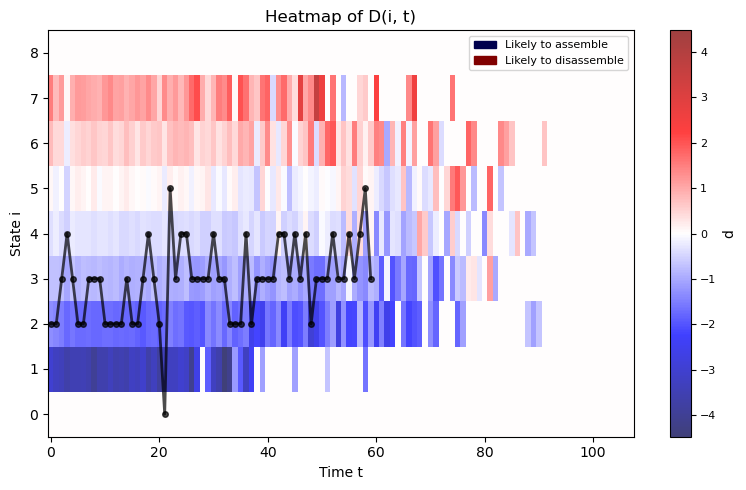

In [10]:
# plot D, along with an example track

import matplotlib.patches as mpatches
import matplotlib.colors as mcolors



# Transpose D if needed so rows = states (i), cols = time (t)
if D.shape[0] == t_max:
    D_plot = D.T
else:
    D_plot = D


# Define diverging colormap centered at 0
vmax = np.max(np.abs(D_plot))
vmin = -vmax
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.seismic

plt.figure(figsize=(8, 5))

# Plot heatmap with lower zorder to be beneath trajectory
im = plt.imshow(
    D_plot,
    cmap=cmap,
    aspect='auto',
    origin='lower',
    interpolation='nearest',
    alpha=0.75,
    norm=norm,  # use norm for clarity
    zorder=1
)

cbar = plt.colorbar(im, label='d')
cbar.ax.tick_params(labelsize=8)

plt.xlabel('Time t')
plt.ylabel('State i')
plt.title('Heatmap of D(i, t)')

plt.yticks(np.arange(D_plot.shape[0]))

# Legend patches — use full min/max values for stronger colors
assembling_patch = mpatches.Patch(color=cmap(norm(vmin)), label='Likely to assemble')
disassembling_patch = mpatches.Patch(color=cmap(norm(vmax)), label='Likely to disassemble')
plt.legend(handles=[assembling_patch, disassembling_patch], loc='upper right', frameon=True, fontsize=8)

# Example track
track = tracks_states[16]

# Check track range for y axis
print("Track min/max:", np.min(track), np.max(track))

plt.plot(
    np.arange(len(track)),
    track,
    color='black',
    marker='o',
    markersize=4,
    alpha=0.7,
    linewidth=2,
    zorder=2,
    label='Trajectory'
)

plt.tight_layout()
plt.show()


# Get statistics across all tracks
## The idea here is to take every track, and convert it to its d track by substituting each (intensity, time) with d(intensity, time)

In [11]:
d_tracks = []
for i in range(len(tracks_states)):
    d = []
    for k in range(len(tracks_states[i])):
        if k == 0:
            d.append(0)
        else:
            d.append(D[tracks_states[i][k], k])

    d_tracks.append(d)

In [12]:
# Calculate the time average(d1)
def d1_distribution(d_tracks, D):
    d1_values = []
    for track in d_tracks:
        T = len(track)
        if T == 0:
            continue
        total = 0
        for t in range(T):
            total += track[t]
        d1 = total / T
        d1_values.append(d1)
    return np.array(d1_values)


In [13]:
#Calculate the normalized max-min difference from the tracks (d2)
def d2_distribution(d_tracks, D):
    d2_values = []
    for track in d_tracks:
        m = max(track)
        small = min(track)
        if (m-small == 0):
            continue
        print((m-small)/len(track))
        d2_values.append(np.log((m-small)/len(track)))
    return np.array(d2_values)


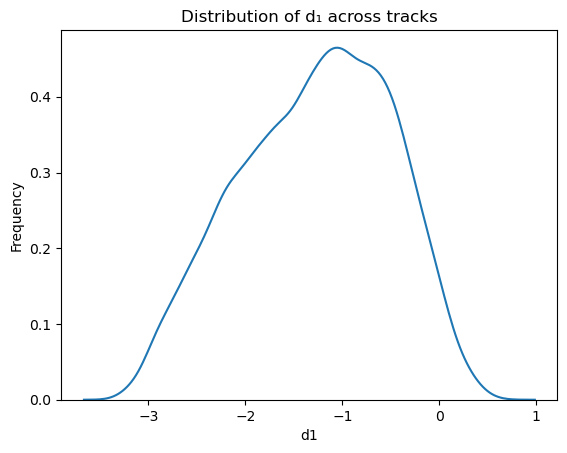

In [14]:
# Plot distribution of d1 and d2
d1_vals = d1_distribution(d_tracks, D)
sns.kdeplot(d1_vals)
plt.xlabel("d1")
plt.ylabel("Frequency")
plt.title("Distribution of d₁ across tracks")
plt.show()


0.0469281833794091
0.04161566735314234
0.04892287069144399
0.04439985971397594
0.08557177228226005
0.06345639867396805
0.05891558886426582
0.053439164569601745
0.07602885532646092
0.06417440815390071
0.08476280415273668
0.06487896650862303
0.06442642519472598
0.07080963820042455
0.05844387833174831
0.06030657785570788
0.055466851827739465
0.0670256019784584
0.06854405993060941
0.07161721337950018
0.05759021390593192
0.05197974169169709
0.04538924144788755
0.06877335396880885
0.07124472582745035
0.06485551070090469
0.050381595894006585
0.04964358140032557
0.05424101925834424
0.08152950481253411
0.09137422070363686
0.08367525889172689
0.07979700594555054
0.06754282270902696
0.07674541731038931
0.08657074017406571
0.09290274739949717
0.08252913440210648
0.05395777433279976
0.08911230624009661
0.05312882518560953
0.05312882518560953
0.06706993168787669
0.09721139666337998
0.04806187598192981
0.08974968230772669
0.10286530096587018
0.09564593353664948
0.08089645860476177
0.05760506677954226

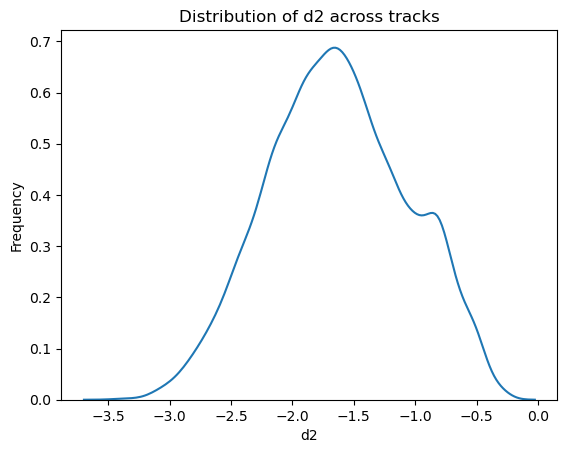

In [15]:
# Plot distribution of d1 and d2
d2_vals = d2_distribution(d_tracks, D)
sns.kdeplot(d2_vals)
plt.xlabel("d2")
plt.ylabel("Frequency")
plt.title("Distribution of d2 across tracks")
plt.show()
